Matplotlib is building the font cache; this may take a moment.


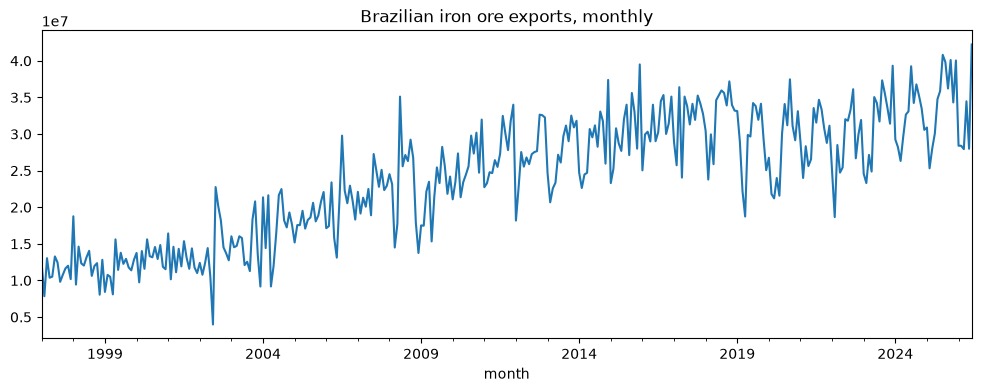

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from quantstats.resample import bootstrap, percentile_ci

df = pd.read_csv("../data/processed/iron_ore_monthly.csv",
                 parse_dates=["month"], index_col="month")
df["tonnes"].plot(figsize=(12, 4), title="Brazilian iron ore exports, monthly")
plt.show()

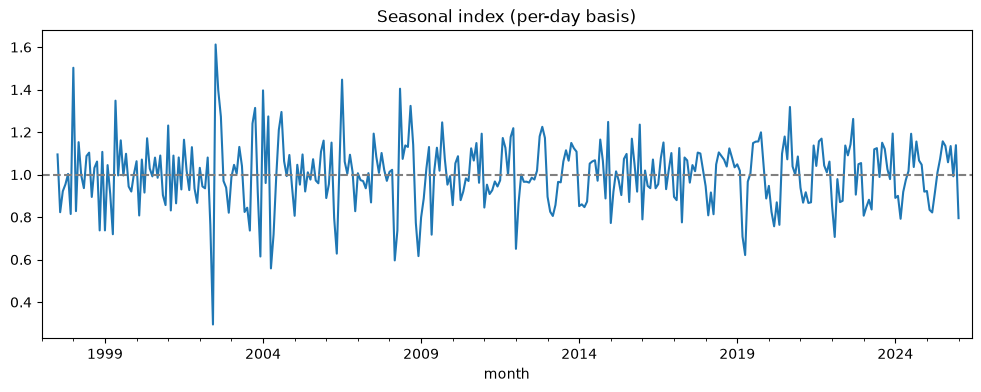

In [7]:
df["tonnes_per_day"] = df["tonnes"] / df.index.days_in_month
trend = df["tonnes_per_day"].rolling(12, center=True).mean()
df["seasonal_index"] = df["tonnes_per_day"] / trend
df["seasonal_index"].plot(figsize=(12, 4), title="Seasonal index (per-day basis)")
plt.axhline(1.0, color="gray", ls="--")
plt.show()

In [8]:
si = df["seasonal_index"].dropna()
results = {}
for m in range(1, 13):
    vals = si[si.index.month == m].values
    reps = bootstrap(vals, n_boot=5000, seed=m)
    lo, hi = percentile_ci(reps)
    results[m] = (vals.mean(), lo, hi)

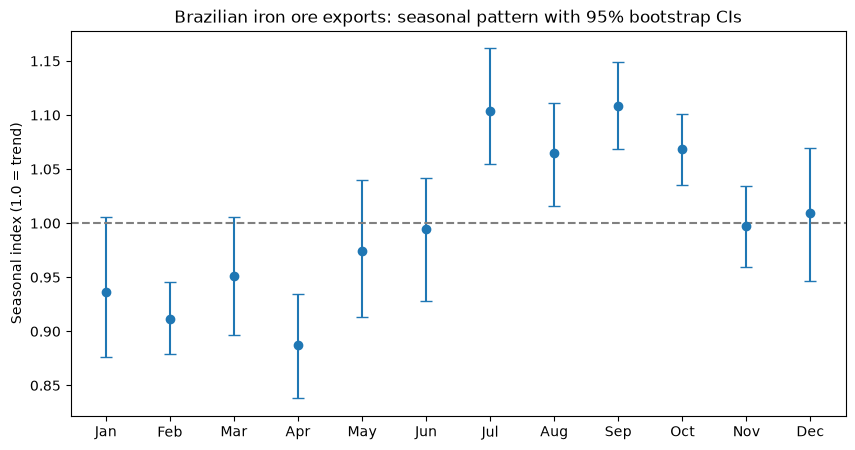

In [9]:
import numpy as np

months = list(results.keys())
means = np.array([results[m][0] for m in months])
los   = np.array([results[m][1] for m in months])
his   = np.array([results[m][2] for m in months])

fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(months, means,
            yerr=[means - los, his - means],   # distances, not levels
            fmt="o", capsize=4)
ax.axhline(1.0, color="gray", ls="--")
ax.set_xticks(months)
ax.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
ax.set_ylabel("Seasonal index (1.0 = trend)")
ax.set_title("Brazilian iron ore exports: seasonal pattern with 95% bootstrap CIs")
plt.show()